In [50]:
%matplotlib inline
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display

sns.set(style="whitegrid")

repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
results_root = os.path.join(repo_root, "results", "approach1")

MODELS = ["SVR_RBF", "GradientBoosting", "HistGradBoost", "RandomForest", "BayesianRidge",
          "Ridge", "ElasticNet", "SVR_Linear", "Lasso", "KNN", "DecisionTree", "Baseline"]

MODEL_TYPE = {
    "SVR_RBF": "Kernel-based",
    "KNN": "Instance-based",
    "RandomForest": "Tree-based",
    "GradientBoosting": "Tree-based",
    "HistGradBoost": "Tree-based",
    "DecisionTree": "Tree-based",
    "Ridge": "Linear",
    "Lasso": "Linear",
    "ElasticNet": "Linear",
    "BayesianRidge": "Linear",
    "SVR_Linear": "Linear",
    "Baseline": "Baseline",
}

TYPE_COLOR = {
    "Kernel-based": "#2e7d32",
    "Baseline": "#9e9e9e",
    "Instance-based": "#e53935",
    "Linear": "#fdd835",
    "Tree-based": "#a5d6a7",
}

# The 4 result sets this notebook reports on: every part below is repeated once per config.
CONFIGS = [
    {"language": "English", "goal": "MAE", "base_dir": os.path.join(results_root, "en_results", "mae_as_goal")},
    {"language": "English", "goal": "RMSE", "base_dir": os.path.join(results_root, "en_results", "rmse_as_goal")},
    {"language": "German", "goal": "MAE", "base_dir": os.path.join(results_root, "de_results", "mae_as_goal")},
    {"language": "German", "goal": "RMSE", "base_dir": os.path.join(results_root, "de_results", "rmse_as_goal")},
]

for cfg in CONFIGS:
    cfg["summary"] = pd.read_csv(os.path.join(cfg["base_dir"], "model_family_summary.csv"))
    cfg["label"] = f"{cfg['language']} — {cfg['goal']} as goal"


def show_heading(cfg):
    display(Markdown(f"#### {cfg['label']}"))

# Part 1. Overall model-family ranking
**Purpose:** Show which model family performs best overall.

#### English — MAE as goal

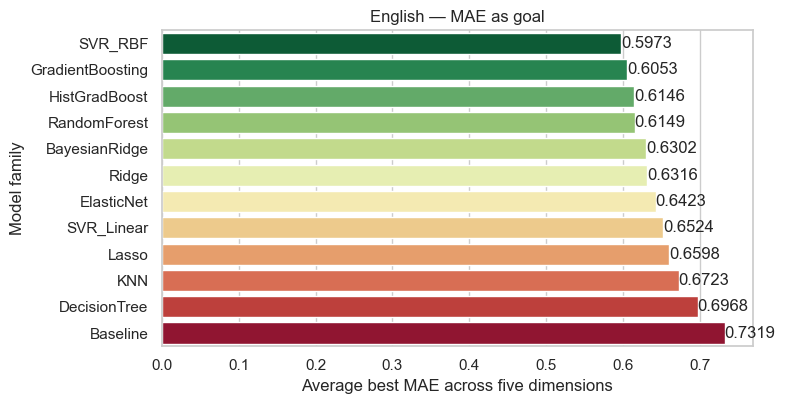

#### English — RMSE as goal

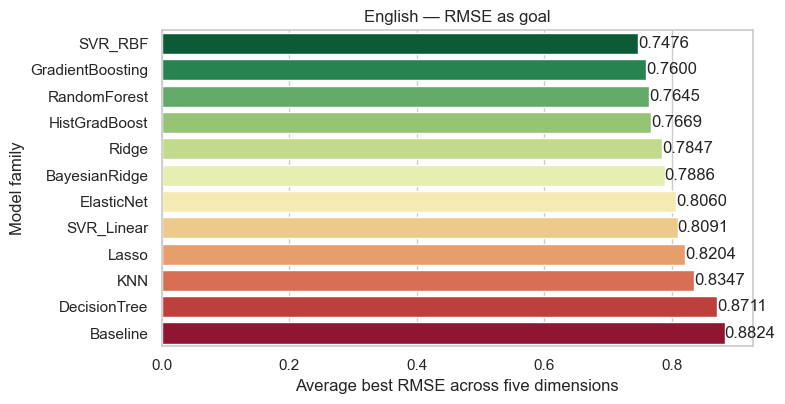

#### German — MAE as goal

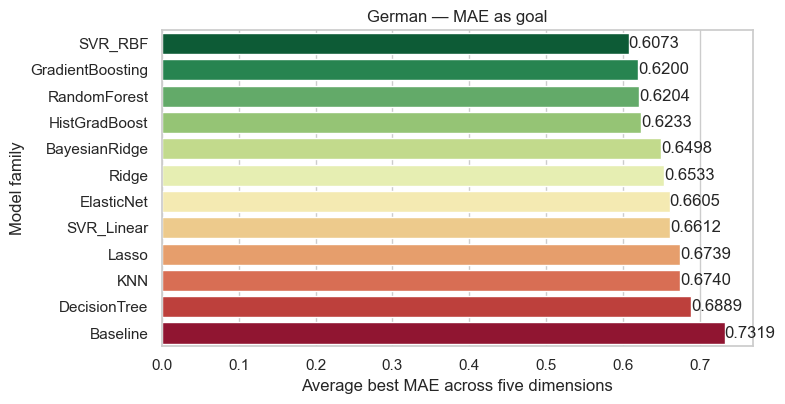

#### German — RMSE as goal

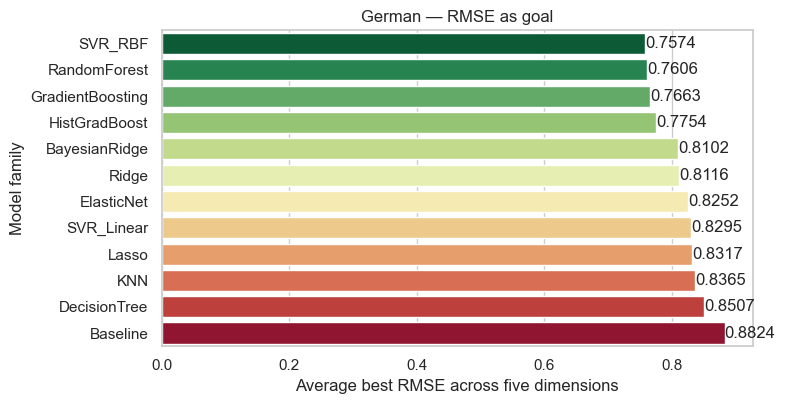

In [51]:
def plot_overall_ranking(cfg):
    metric_col = f"best_{cfg['goal']}"
    avg_best = cfg["summary"].groupby("model_family")[metric_col].mean()

    df = pd.DataFrame({"model": MODELS, "avg_best": [avg_best.get(m, np.nan) for m in MODELS]}).set_index("model")
    df_sorted = df.sort_values("avg_best", na_position="last").reset_index()

    plt.figure(figsize=(8, max(4, len(df_sorted) * 0.35)))
    n = len(df_sorted)
    cmap = plt.cm.RdYlGn
    colors = [cmap(1 - i / max(n - 1, 1)) for i in range(n)]
    ax = sns.barplot(x="avg_best", y="model", data=df_sorted, hue="model", palette=colors, legend=False)
    ax.set_xlabel(f"Average best {cfg['goal']} across five dimensions")
    ax.set_ylabel("Model family")
    for p in ax.patches:
        x = p.get_width()
        if not np.isnan(x):
            ax.text(x + 1e-6, p.get_y() + p.get_height() / 2, f"{x:.4f}", va="center")
    plt.title(cfg["label"])
    plt.tight_layout()
    plt.show()
    plt.close()


for cfg in CONFIGS:
    show_heading(cfg)
    plot_overall_ranking(cfg)

# Part 2. Best model per dimension (radar)
**Purpose:** Show that the best-performing family differs by dimension.

#### English — MAE as goal

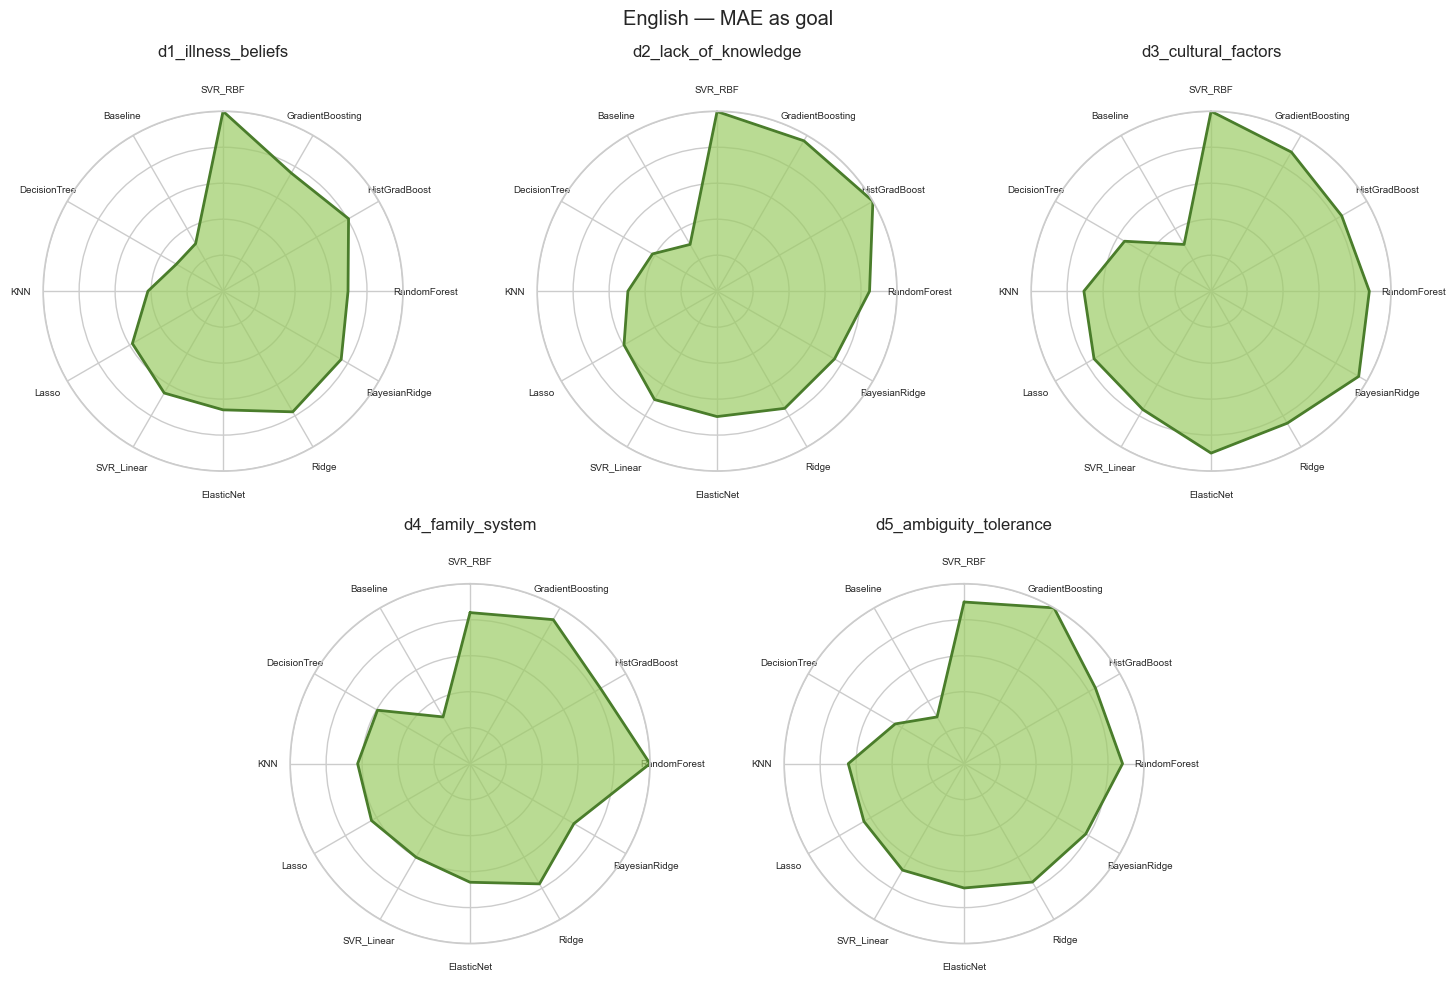

#### English — RMSE as goal

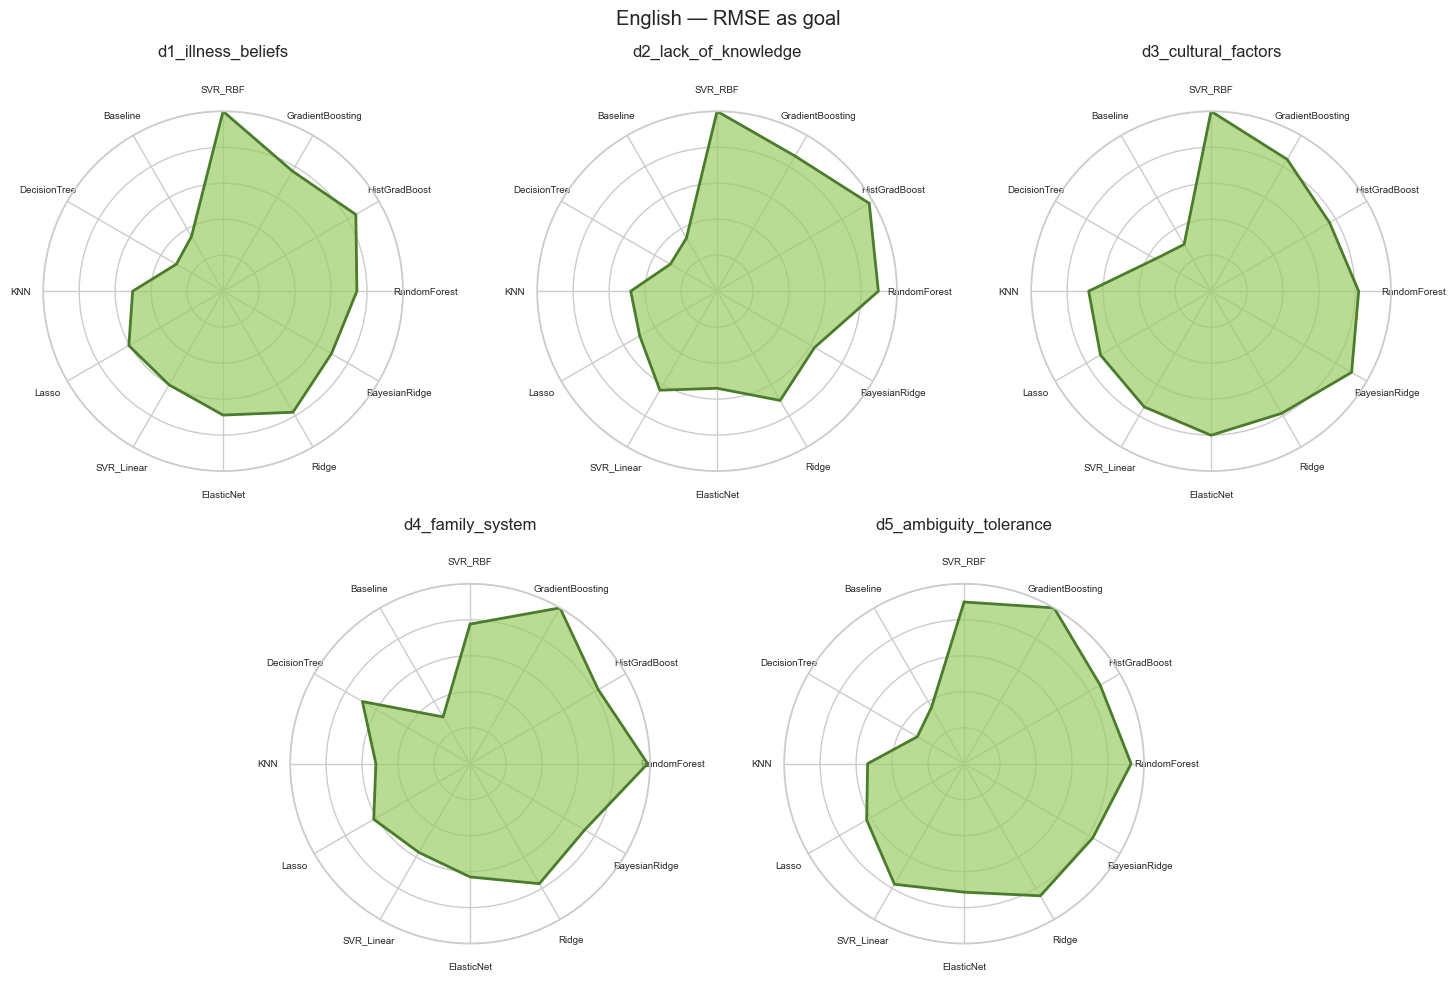

#### German — MAE as goal

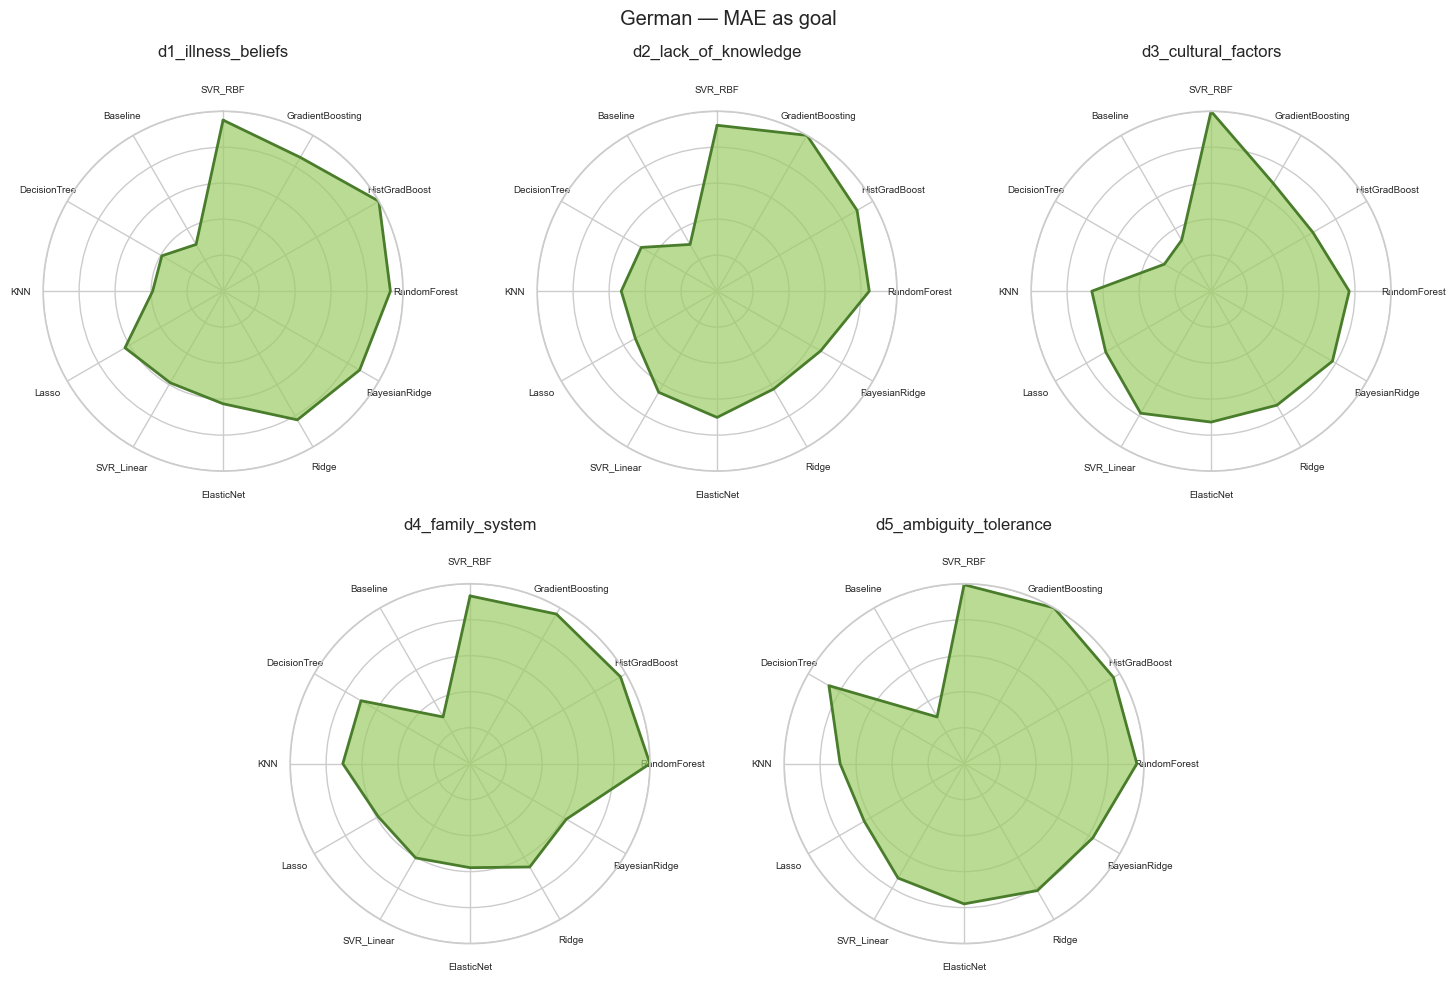

#### German — RMSE as goal

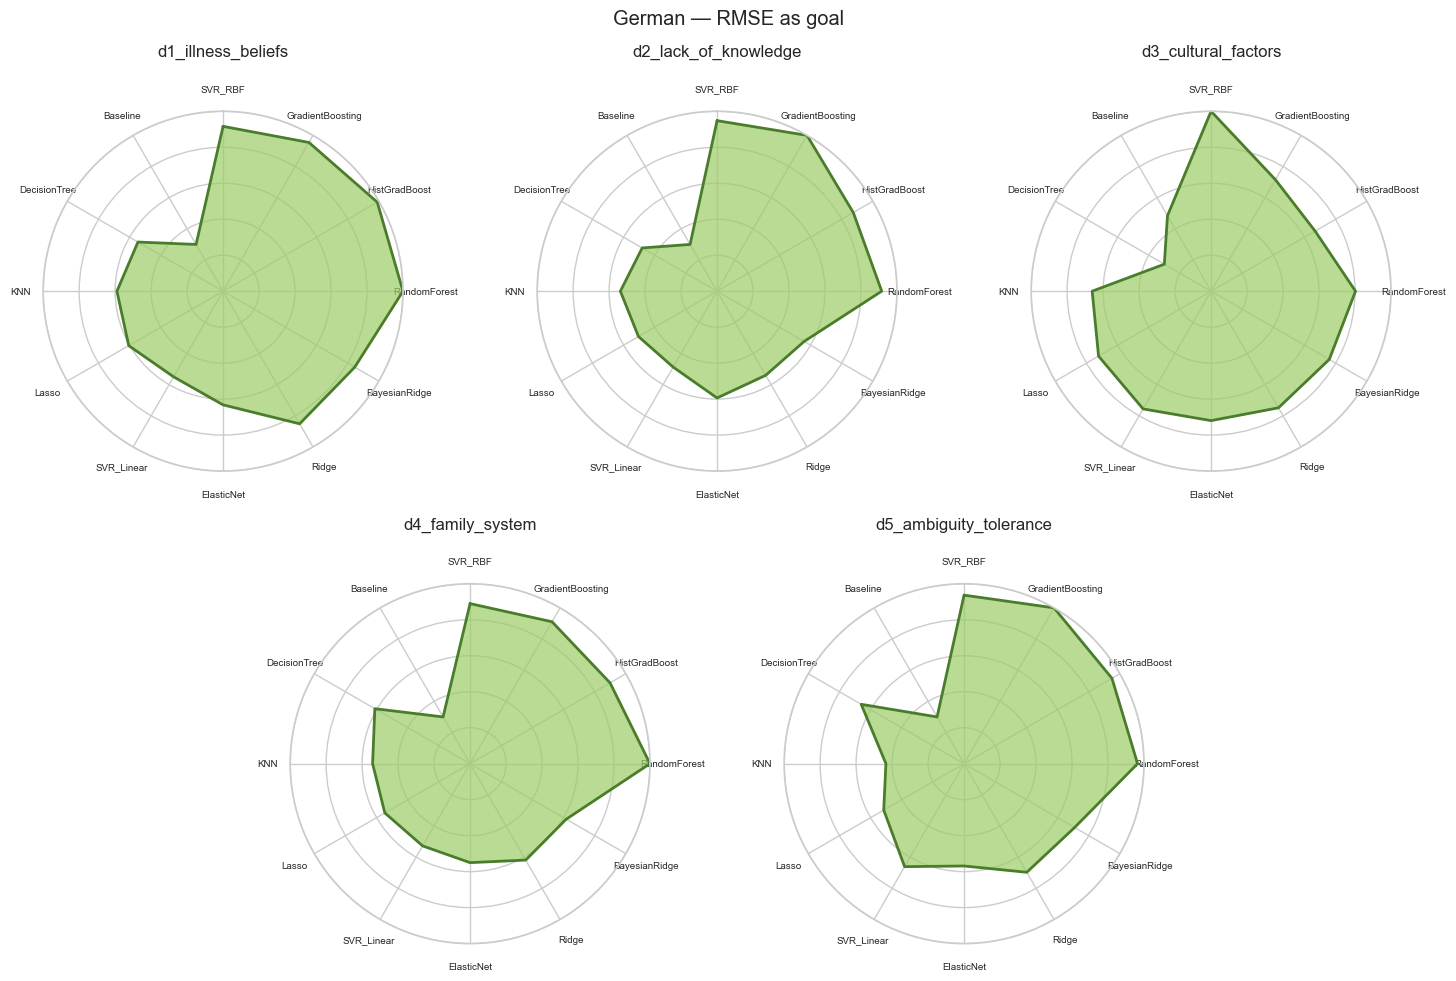

In [52]:
def plot_radar(cfg):
    metric_col = f"best_{cfg['goal']}"
    summary = cfg["summary"]
    dimensions = sorted(summary["dimension"].unique())
    model_order = MODELS

    n_axes = len(model_order)
    angles = [i / n_axes * 2 * np.pi for i in range(n_axes)]
    angles += angles[:1]

    fig = plt.figure(figsize=(15, 10))
    fig.suptitle(cfg["label"])
    gs = fig.add_gridspec(2, 6)
    positions = [gs[0, 0:2], gs[0, 2:4], gs[0, 4:6], gs[1, 1:3], gs[1, 3:5]]
    axes = [fig.add_subplot(pos, polar=True) for pos in positions]

    for ax, dim in zip(axes, dimensions):
        dim_df = summary[summary["dimension"] == dim].set_index("model_family")[metric_col]
        vals = [dim_df.get(m, np.nan) for m in model_order]

        worst, best = np.nanmax(vals), np.nanmin(vals)
        performance = [1 - (v - best) / (worst - best) * 0.7 if not np.isnan(v) else 0 for v in vals]
        performance_closed = performance + performance[:1]

        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.plot(angles, performance_closed, color="#4a7d2b", linewidth=2)
        ax.fill(angles, performance_closed, color="#9ccc65", alpha=0.7)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(model_order, fontsize=7)
        ax.set_yticklabels([])
        ax.set_ylim(0, 1)
        ax.set_title(dim, pad=20)

    plt.tight_layout()
    plt.show()
    plt.close()


for cfg in CONFIGS:
    show_heading(cfg)
    plot_radar(cfg)

# Part 3. Best model per dimension (grouped bar, optional view)

#### English — MAE as goal

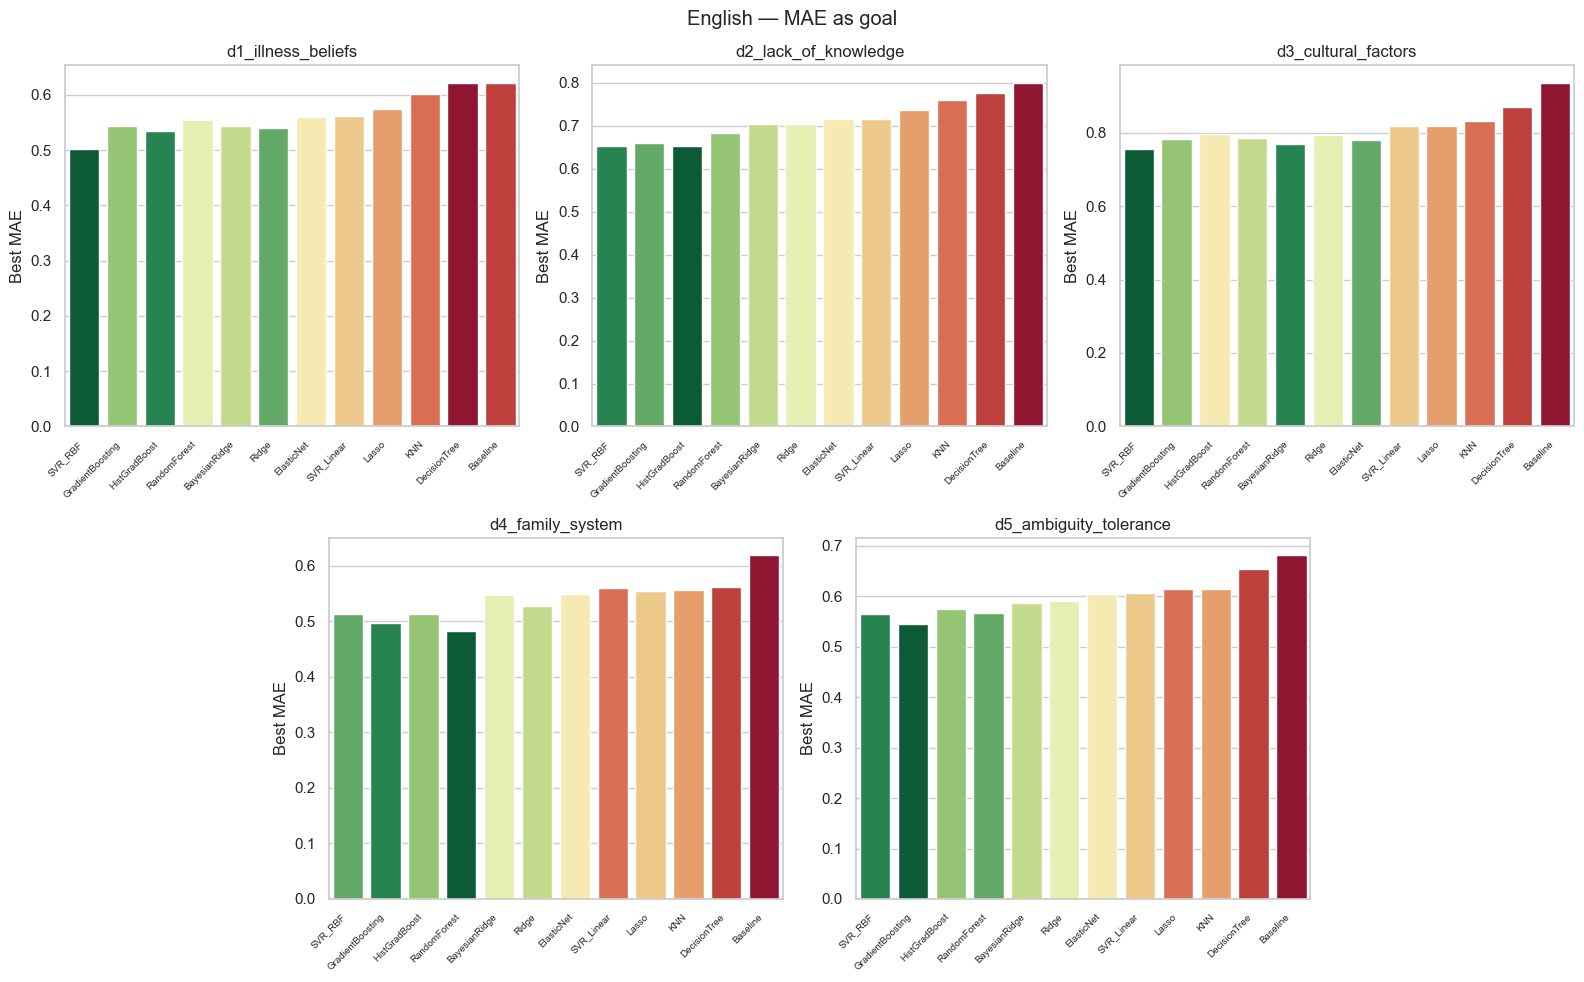

#### English — RMSE as goal

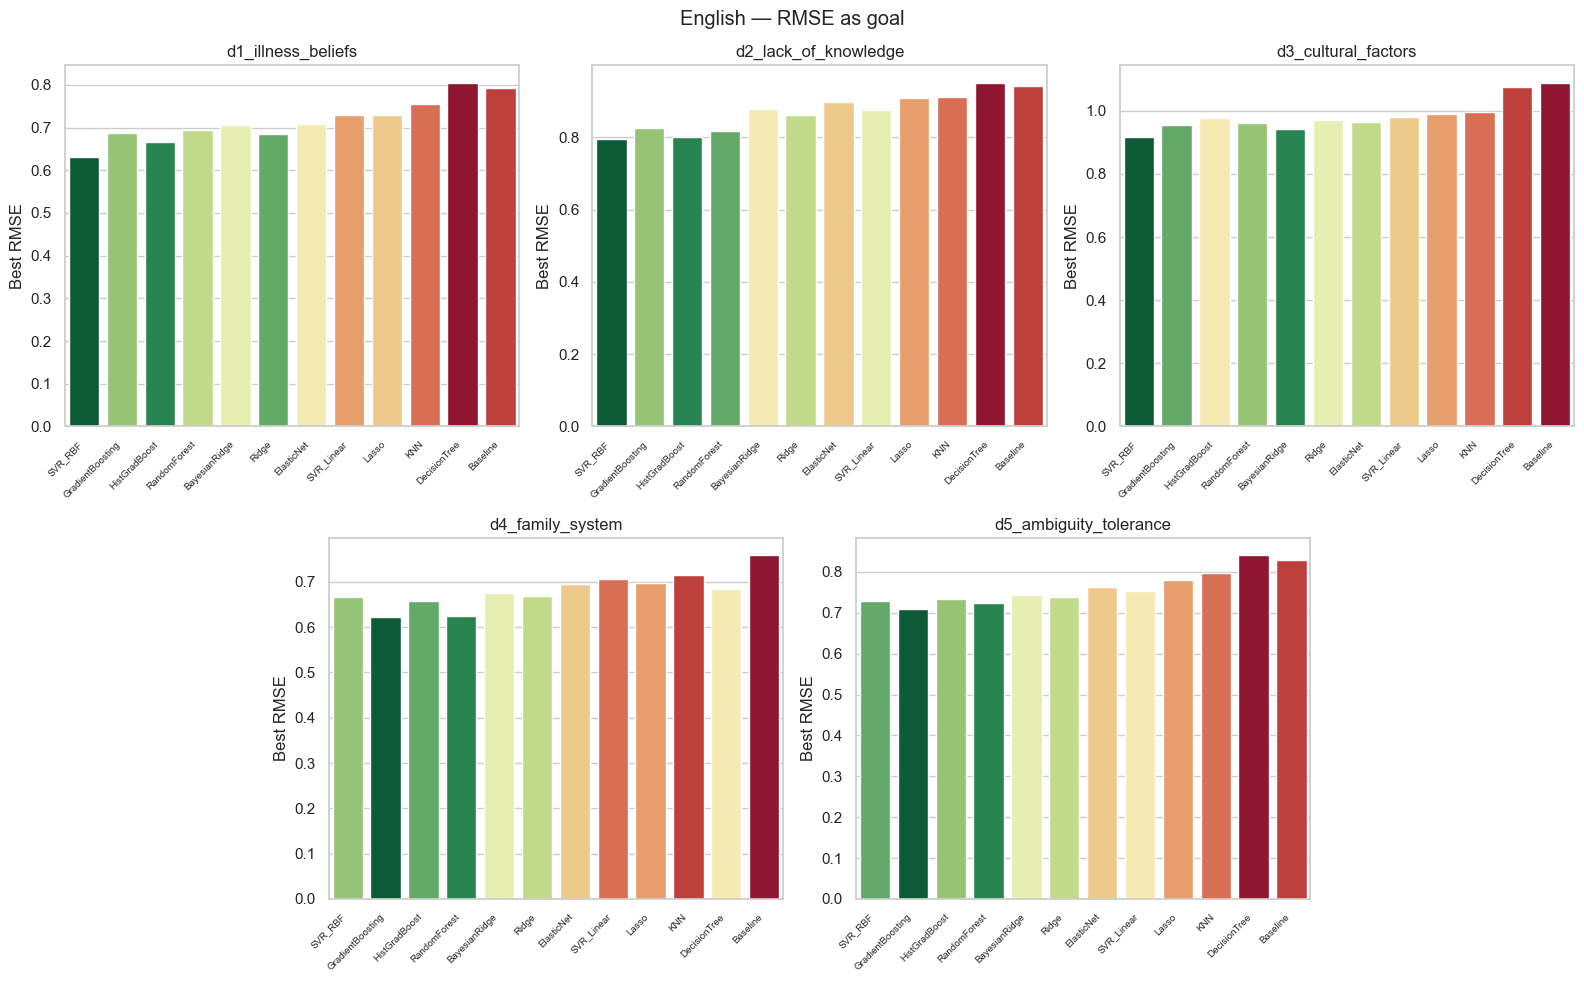

#### German — MAE as goal

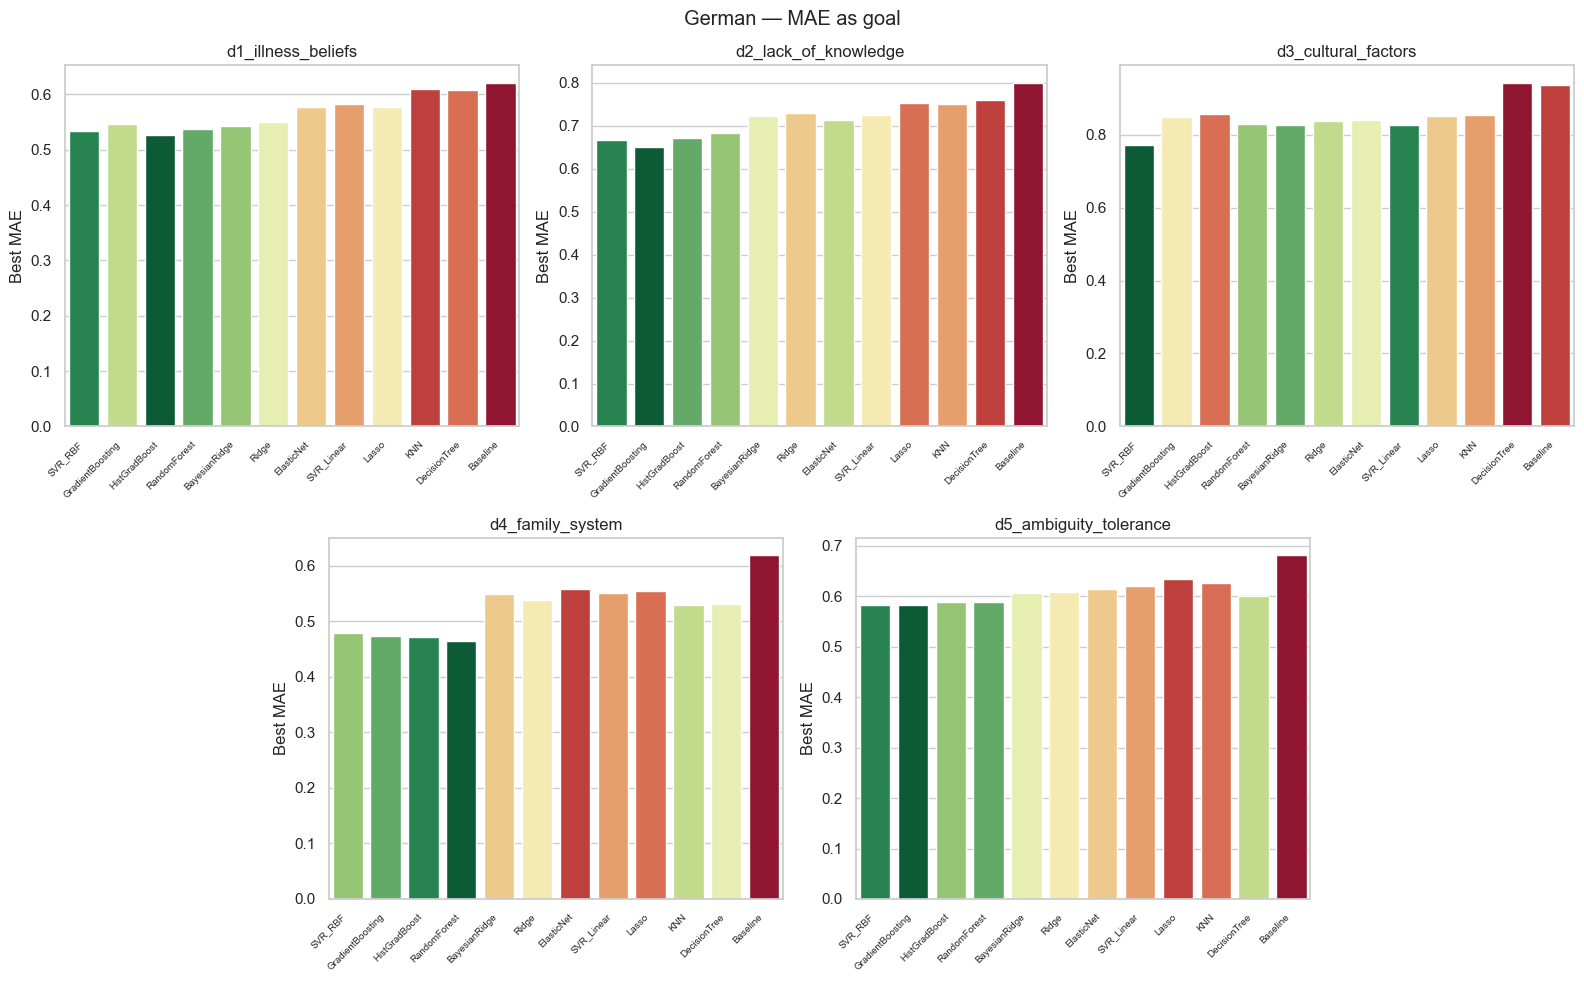

#### German — RMSE as goal

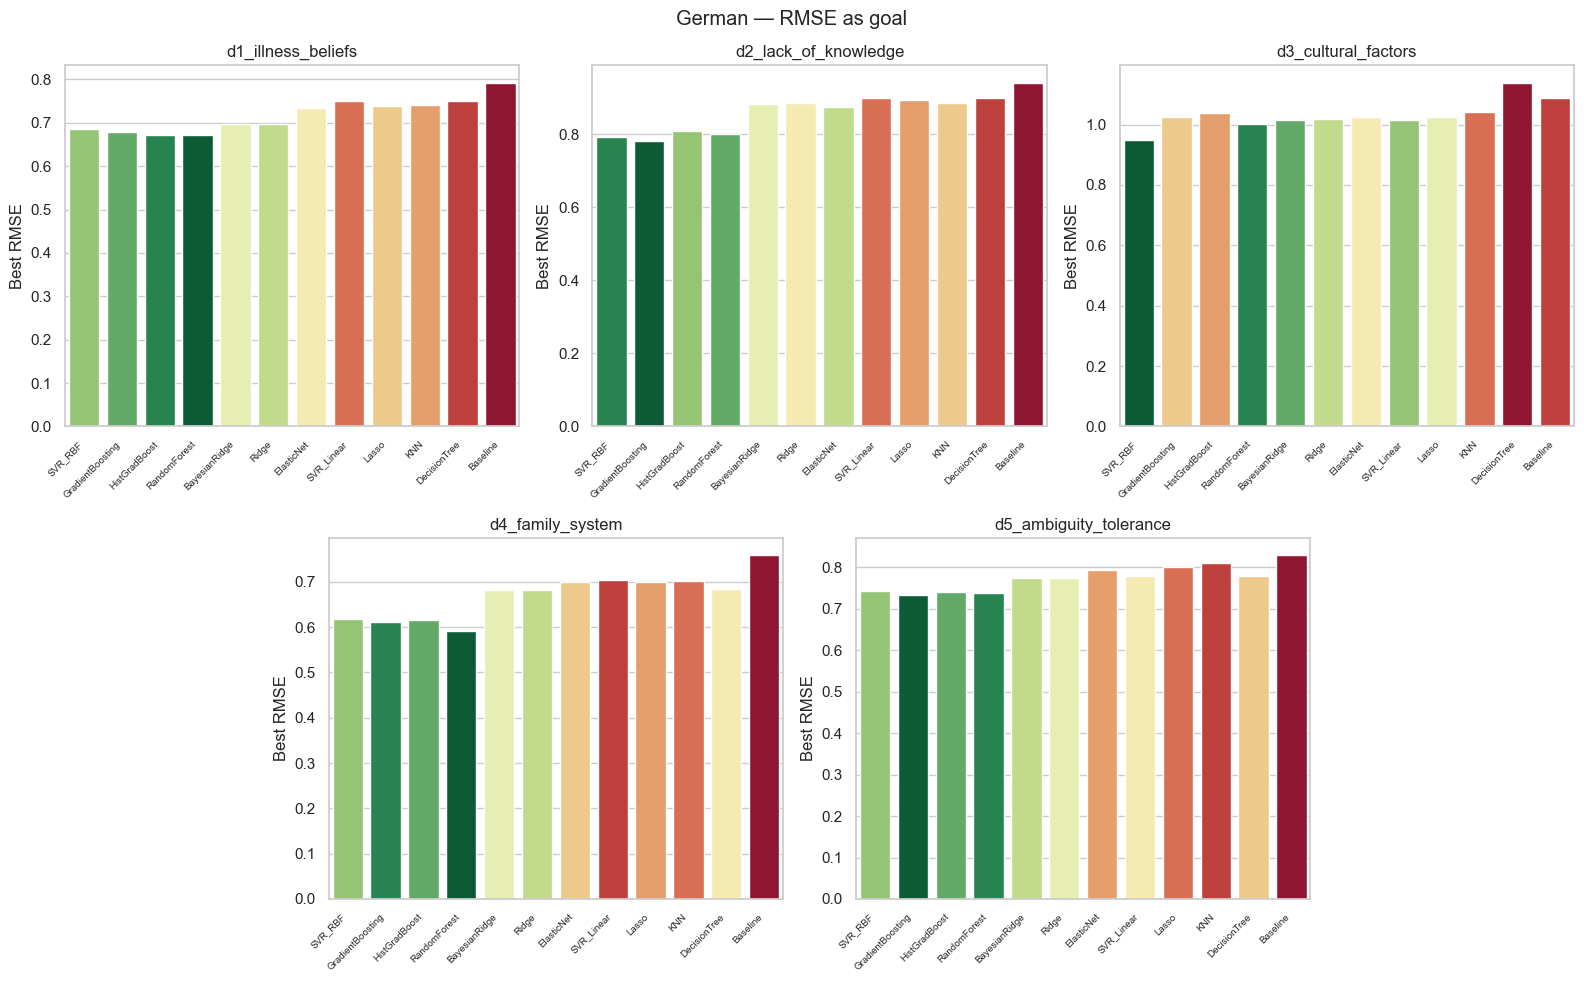

In [53]:
def plot_grouped_bar(cfg):
    metric_col = f"best_{cfg['goal']}"
    summary = cfg["summary"]
    dimensions = sorted(summary["dimension"].unique())
    model_order = MODELS

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(cfg["label"])
    gs = fig.add_gridspec(2, 6)
    positions = [gs[0, 0:2], gs[0, 2:4], gs[0, 4:6], gs[1, 1:3], gs[1, 3:5]]
    axes = [fig.add_subplot(pos) for pos in positions]

    for ax, dim in zip(axes, dimensions):
        dim_df = summary[summary["dimension"] == dim].set_index("model_family")[metric_col]
        vals = [dim_df.get(m, np.nan) for m in model_order]
        dim_plot_df = pd.DataFrame({"model_family": model_order, "value": vals})

        n = len(dim_plot_df)
        cmap = plt.cm.RdYlGn
        order = np.argsort(dim_plot_df["value"].values)
        ranks = np.empty(n, dtype=int)
        ranks[order] = np.arange(n)
        colors = [cmap(1 - r / max(n - 1, 1)) for r in ranks]

        sns.barplot(x="model_family", y="value", data=dim_plot_df, hue="model_family", palette=colors, legend=False, ax=ax)
        ax.set_title(dim)
        ax.set_xlabel("")
        ax.set_ylabel(f"Best {cfg['goal']}")
        ax.set_xticks(range(len(model_order)))
        ax.set_xticklabels(model_order, rotation=45, ha="right", fontsize=7)

    plt.tight_layout()
    plt.show()
    plt.close()


for cfg in CONFIGS:
    show_heading(cfg)
    plot_grouped_bar(cfg)

# Part 4. Best model vs baseline
**Purpose:** Show that your models are meaningfully better than a dummy baseline.

#### English — MAE as goal

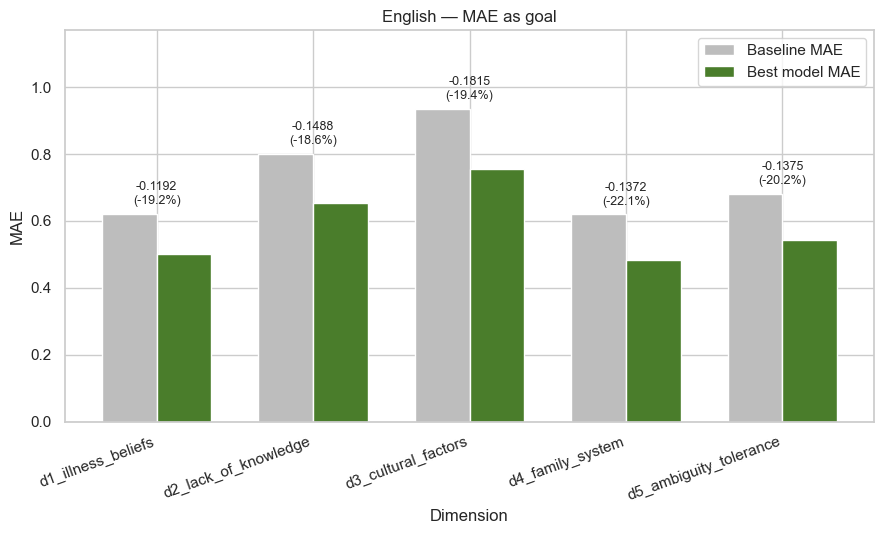

#### English — RMSE as goal

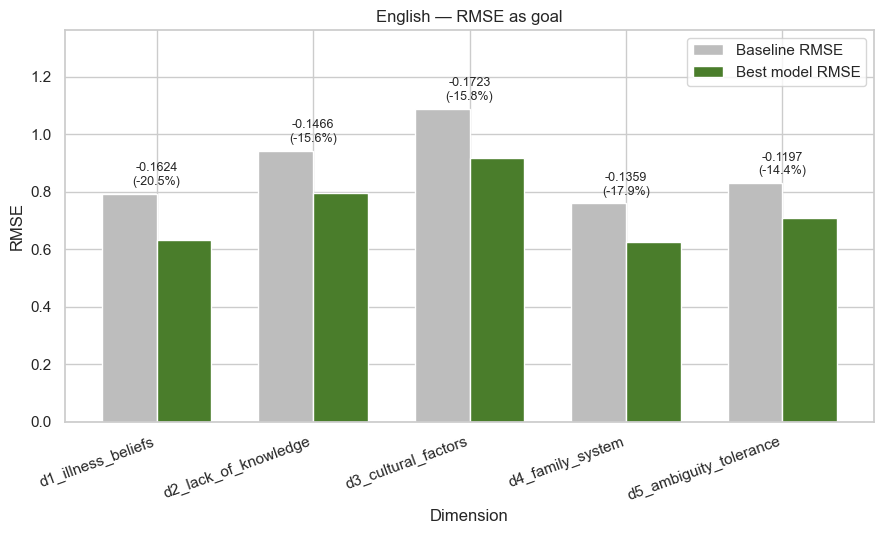

#### German — MAE as goal

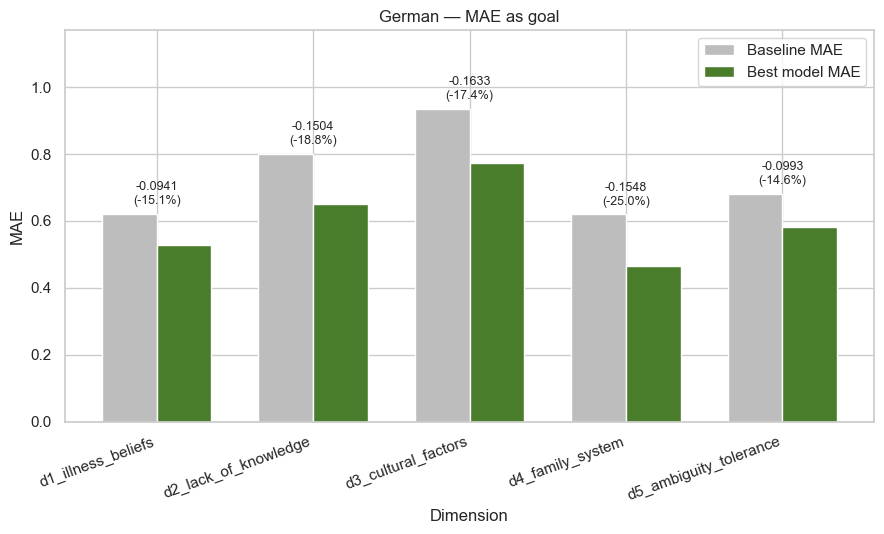

#### German — RMSE as goal

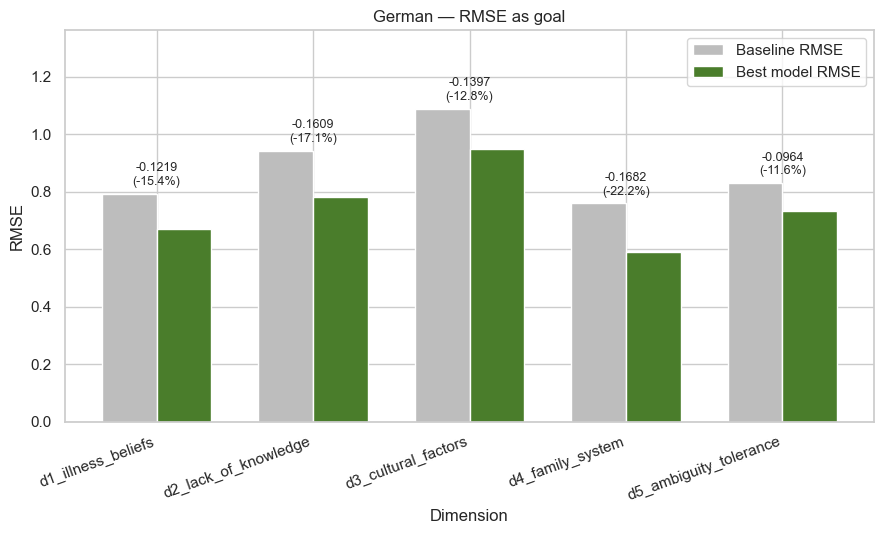

In [54]:
def plot_best_vs_baseline(cfg):
    metric = cfg["goal"]
    bvb = pd.read_csv(
        os.path.join(cfg["base_dir"], "best_vs_baseline.csv"),
        usecols=["dimension", metric, f"baseline_{metric}", f"{metric}_improvement_vs_baseline"],
    )
    bvb = bvb.sort_values("dimension").reset_index(drop=True)
    bvb["improvement_pct"] = bvb[f"{metric}_improvement_vs_baseline"] / bvb[f"baseline_{metric}"] * 100

    x = np.arange(len(bvb))
    width = 0.35

    plt.figure(figsize=(9, 5.5))
    plt.bar(x - width / 2, bvb[f"baseline_{metric}"], width, label=f"Baseline {metric}", color="#bdbdbd")
    plt.bar(x + width / 2, bvb[metric], width, label=f"Best model {metric}", color="#4a7d2b")

    for xi, base, best, imp, imp_pct in zip(
        x, bvb[f"baseline_{metric}"], bvb[metric], bvb[f"{metric}_improvement_vs_baseline"], bvb["improvement_pct"]
    ):
        top = max(base, best)
        plt.text(xi, top + 0.02, f"-{imp:.4f}\n(-{imp_pct:.1f}%)", ha="center", va="bottom", fontsize=9)

    plt.xticks(x, bvb["dimension"], rotation=20, ha="right")
    plt.xlabel("Dimension")
    plt.ylabel(metric)
    plt.ylim(0, bvb[[f"baseline_{metric}", metric]].values.max() * 1.25)
    plt.title(cfg["label"])
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()


for cfg in CONFIGS:
    show_heading(cfg)
    plot_best_vs_baseline(cfg)

# Part 5. Heatmap of model-family performance across dimensions
**Purpose:** Show the full pattern instead of only the winners.

#### English — MAE as goal

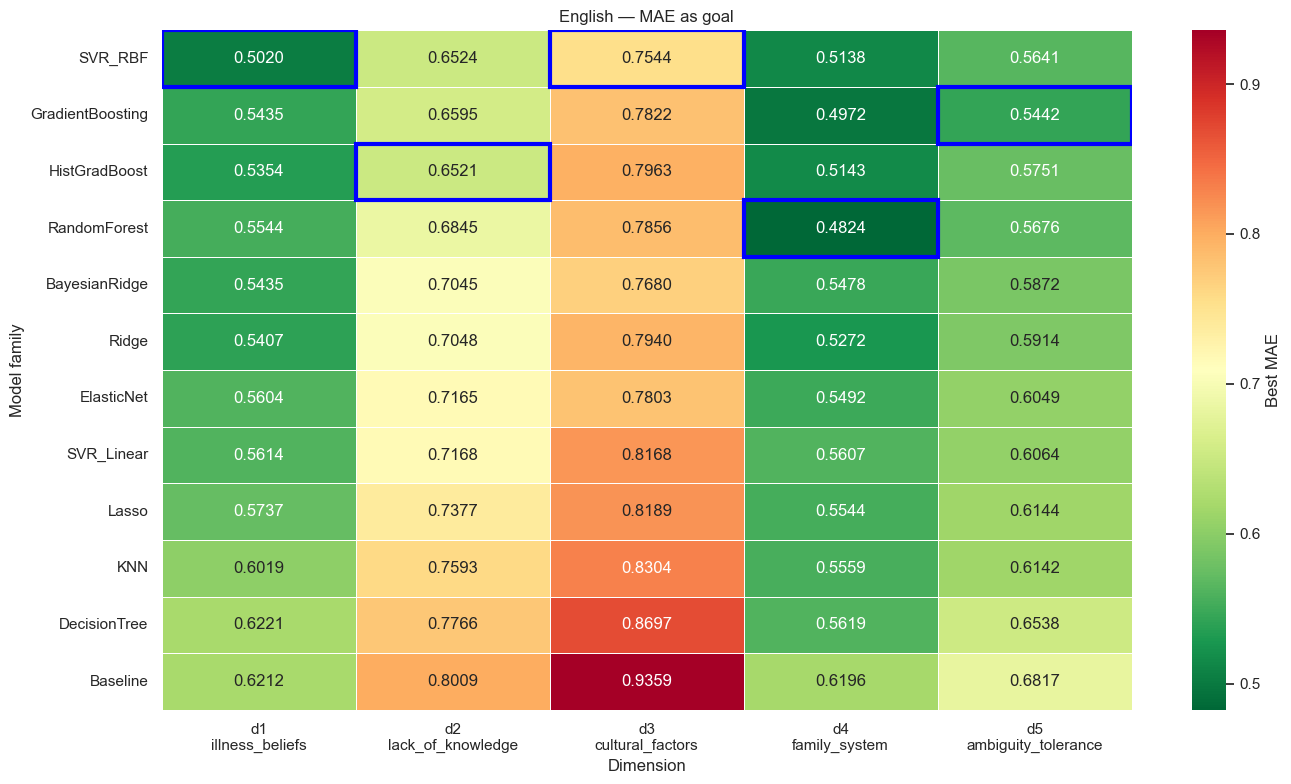

#### English — RMSE as goal

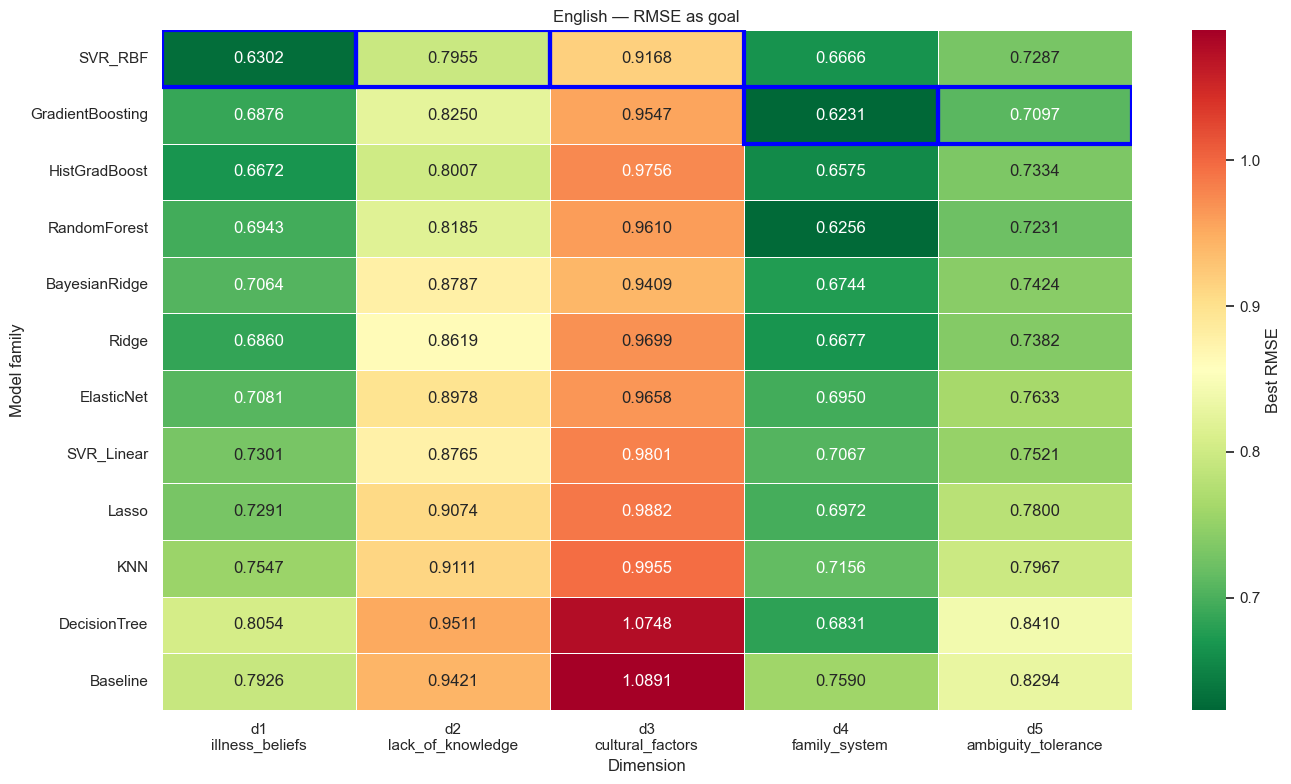

#### German — MAE as goal

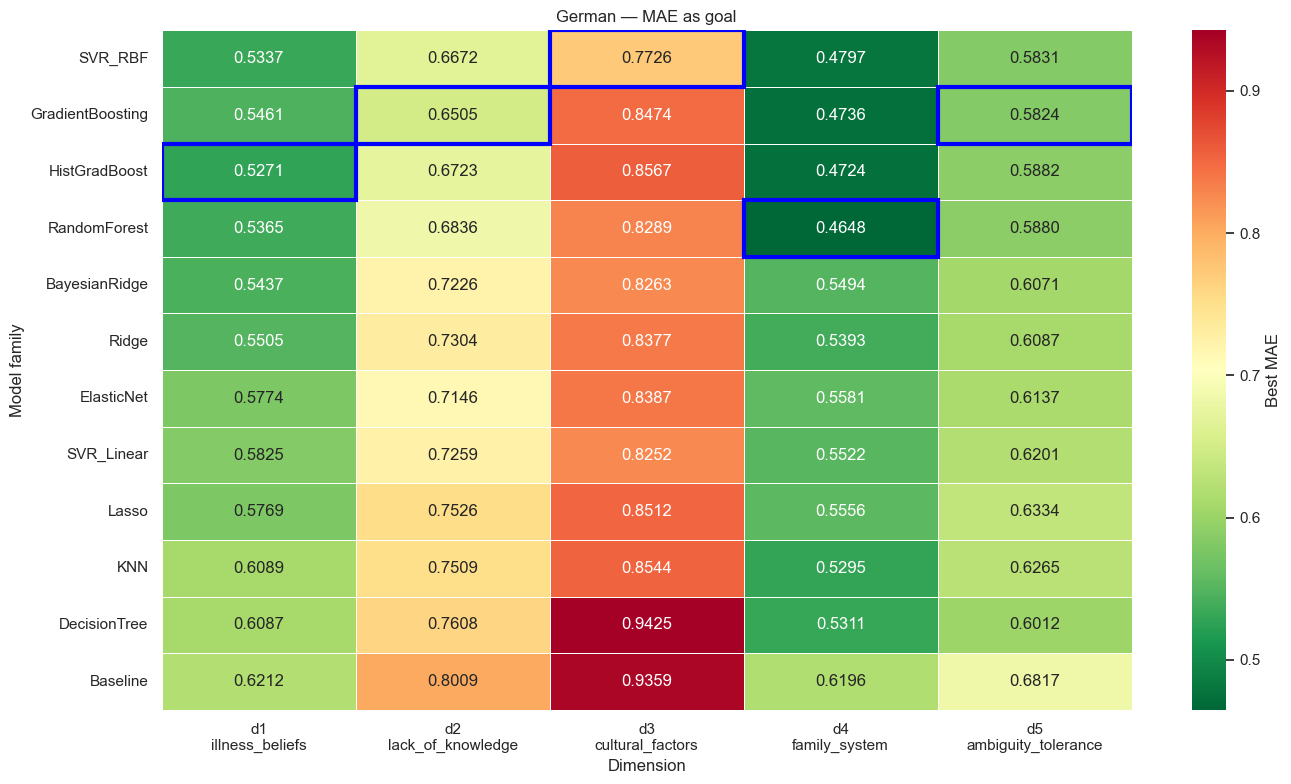

#### German — RMSE as goal

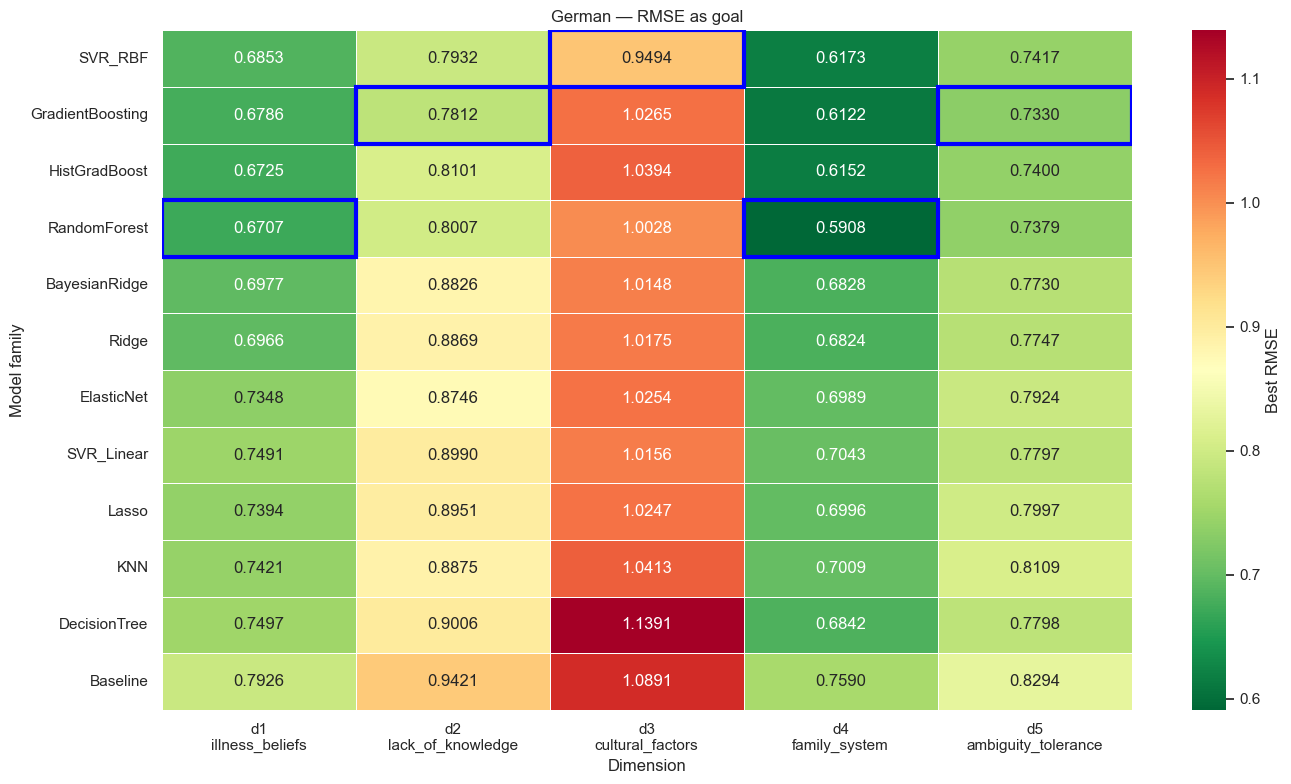

In [55]:
def plot_heatmap(cfg):
    metric_col = f"best_{cfg['goal']}"
    summary = cfg["summary"]
    model_order = MODELS
    dimensions = sorted(summary["dimension"].unique())

    pivot = summary.pivot_table(index="model_family", columns="dimension", values=metric_col)
    pivot = pivot.reindex(index=model_order, columns=dimensions)

    plt.figure(figsize=(14, 8))
    ax = sns.heatmap(pivot, annot=True, fmt=".4f", cmap="RdYlGn_r", linewidths=0.5, linecolor="white",
                      cbar_kws={"label": f"Best {cfg['goal']}"})
    ax.set_xlabel("Dimension")
    ax.set_ylabel("Model family")
    ax.set_title(cfg["label"])

    wrapped_labels = [dim.replace("_", "\n", 1) for dim in dimensions]
    ax.set_xticklabels(wrapped_labels, rotation=0, ha="center", fontsize=11)

    for col_idx, dim in enumerate(dimensions):
        row_idx = pivot[dim].values.argmin()
        ax.add_patch(plt.Rectangle((col_idx, row_idx), 1, 1, fill=False, edgecolor="blue", lw=3))

    plt.tight_layout()
    plt.show()
    plt.close()


for cfg in CONFIGS:
    show_heading(cfg)
    plot_heatmap(cfg)

# Part 6. Metric comparison by model type
**Purpose:** Show that the conclusion is not based on a single metric alone.

#### English — MAE as goal

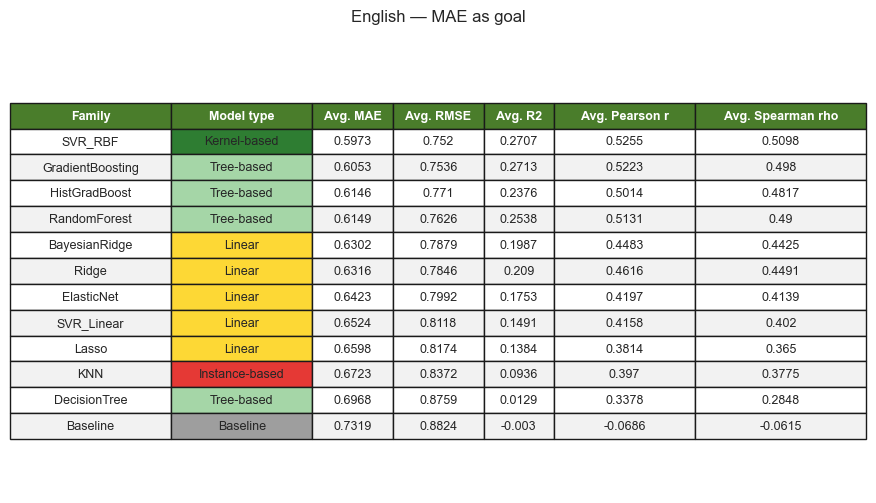

#### English — RMSE as goal

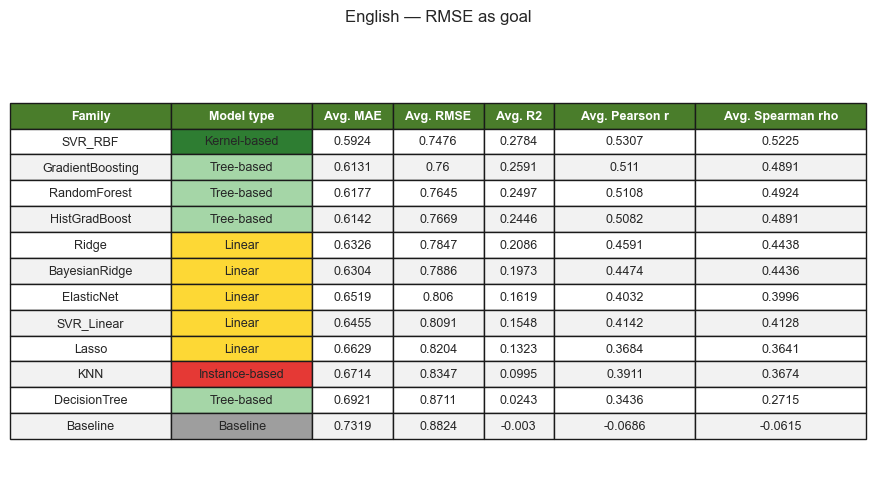

#### German — MAE as goal

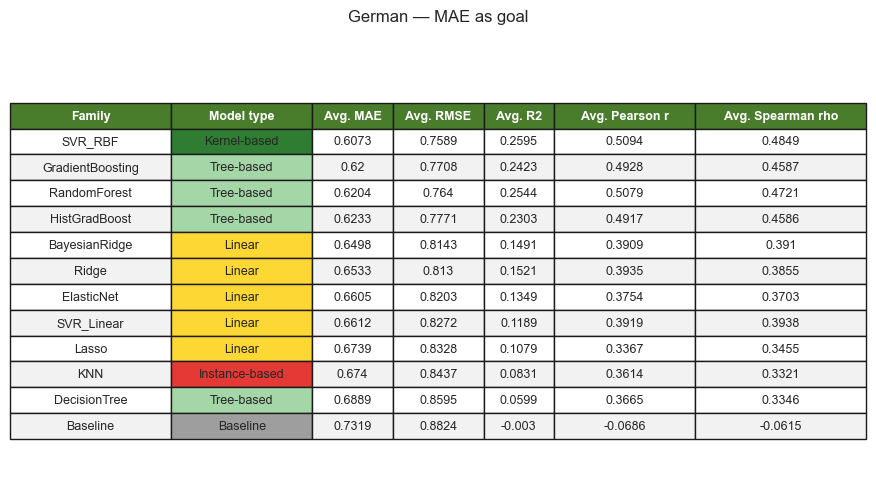

#### German — RMSE as goal

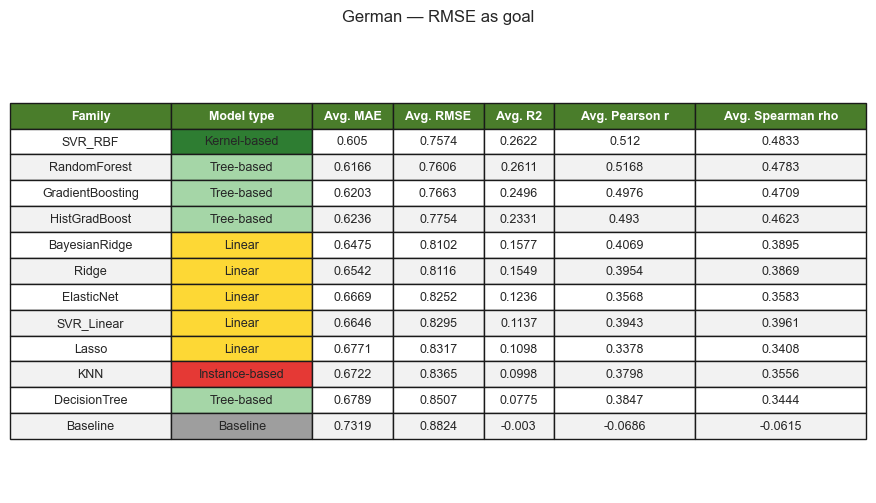

In [56]:
def plot_metric_table(cfg):
    metrics = ["best_MAE", "best_RMSE", "best_R2", "best_Pearson_r", "best_Spearman_rho"]
    avg_metrics = cfg["summary"].groupby("model_family")[metrics].mean()
    avg_metrics.columns = ["Avg. MAE", "Avg. RMSE", "Avg. R2", "Avg. Pearson r", "Avg. Spearman rho"]

    sort_col = f"Avg. {cfg['goal']}"
    all_families = avg_metrics.sort_values(sort_col).round(4).reset_index()
    all_families = all_families.rename(columns={"model_family": "Family"})
    all_families.insert(1, "Model type", all_families["Family"].map(MODEL_TYPE))

    max_chars = [
        max(len(col), all_families[col].astype(str).str.len().max())
        for col in all_families.columns
    ]
    total_chars = sum(max_chars)
    col_widths = [c / total_chars for c in max_chars]

    fig, ax = plt.subplots(figsize=(0.105 * total_chars, 1.0 + 0.35 * len(all_families)))
    ax.axis("off")
    ax.set_title(cfg["label"], pad=20)
    tbl = ax.table(cellText=all_families.values, colLabels=all_families.columns, cellLoc="center", loc="center",
                   colWidths=col_widths)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.4)

    model_type_col = all_families.columns.get_loc("Model type")
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#4a7d2b")
            cell.set_text_props(color="white", weight="bold")
        elif col == model_type_col:
            cell.set_facecolor(TYPE_COLOR[all_families.iloc[row - 1]["Model type"]])
        else:
            cell.set_facecolor("#f2f2f2" if row % 2 == 0 else "white")

    plt.tight_layout()
    plt.show()
    plt.close()


for cfg in CONFIGS:
    show_heading(cfg)
    plot_metric_table(cfg)